In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("online_retail_II 2009-2010.csv", encoding="ISO-8859-1")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,12/9/2010 20:01,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,12/9/2010 20:01,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,12/9/2010 20:01,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,12/9/2010 20:01,3.75,17530.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [4]:
for i in df:
    print(i,":",df[i].unique())
    print("*****************************")

Invoice : ['489434' '489435' '489436' ... '538169' '538170' '538171']
*****************************
StockCode : ['85048' '79323P' '79323W' ... '22935' '22933' '21120']
*****************************
Description : ['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' ... '*Boombox Ipod Classic' 'faulty'
 'Dotcom sales']
*****************************
Quantity : [   12    48    24    10    18     3    16     4     2     6     8     1
    28    30    60    32    56     9    25    36    20   -12    -6    -4
   -24    -3    -2   576   288    27   -96    64   160  -240  -192     5
    -1    72    50    54   -50     7   800    11    58   192    96   144
   100   180   216    15   240    22   108    33    90    81   -81   -48
    17    -5    14    13    40    -8    -9    21   120   -44   230 -1043
  -117   200   168    19   280   128  -150   -18   -23    80   300   450
    61  -770  -720   480    -7    88    46   -31   -16   954  -954  -200
   504    45   467 -1012 

In [5]:
df.shape

(525461, 8)

In [6]:
df.groupby('Country')['Country'].agg('count')

Country
Australia                  654
Austria                    537
Bahrain                    107
Belgium                   1054
Bermuda                     34
Brazil                      62
Canada                      77
Channel Islands            906
Cyprus                     554
Denmark                    428
EIRE                      9670
Finland                    354
France                    5772
Germany                   8129
Greece                     517
Hong Kong                   76
Iceland                     71
Israel                      74
Italy                      731
Japan                      224
Korea                       63
Lebanon                     13
Lithuania                  154
Malta                      172
Netherlands               2769
Nigeria                     32
Norway                     369
Poland                     194
Portugal                  1101
RSA                        111
Singapore                  117
Spain                     1278


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

# Phase 1: Data Cleaning

In [8]:

# Remove records without Customer ID (Primary key for our analysis)
# we have not used df2 because it have some problem with the data
df3 = df.dropna(subset=['Customer ID'])

In [9]:
df3.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [10]:
# Filter out cancellations (Invoice numbers starting with 'C')
# We treat returns separately in feature engineering, but for basic EDA we want successful sales
df3 = df[~df['Invoice'].str.startswith('C', na=False)]

In [11]:
# Remove negative or zero quantities and prices (removes bad data/stock adjustments)
df3 = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [12]:
for i in df3:
    print(i,":",df3[i].unique())
    print("*****************************")

Invoice : ['489434' '489435' '489436' ... '538169' '538170' '538171']
*****************************
StockCode : ['85048' '79323P' '79323W' ... '22935' '22933' '21120']
*****************************
Description : ['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' ... 'BAKING MOULD CHOCOLATE CUP CAKES'
 'BAKING MOULD EASTER EGG MILK CHOC' '*Boombox Ipod Classic']
*****************************
Quantity : [   12    48    24    10    18     3    16     4     2     6     8     1
    28    30    60    32    56     9    25    36    20   576   288    27
    64   160     5    72    50    54     7   800    11    58   192    96
   144   100   180   216    15   240    22   108    33    90    81    17
    14    13    40    21   120   200   168    19   280   128    80   300
   450    61   480    88    46   504    45  4320  5184  4008   600   505
   500    23    74    47   432   252    75    31    38   360   107    49
    42    66    34    52   400    70   936    35   

In [13]:
# Convert InvoiceDate to datetime objects
df3['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df3

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [15]:
# 3. Feature Creation
# Calculate TotalPrice ($Quantity \times Price$)
df3['TotalPrice'] = df['Quantity'] * df['Price']

In [16]:
df3

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [17]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,12/9/2010 20:01,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,12/9/2010 20:01,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,12/9/2010 20:01,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,12/9/2010 20:01,3.75,17530.0,United Kingdom


In [19]:
# Extract Month for seasonality analysis
# df3['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

In [ ]:
df3

In [ ]:
print(f"Cleaning Complete. Remaining rows: {len(df3)}")
print(f"Unique Customers identified: {df3['Customer ID'].nunique()}")

In [ ]:
# 4. Exploratory Data Analysis (EDA)

# Visualizing Revenue by Country (Top 10)
country_rev = df3.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=country_rev.values, y=country_rev.index, hue=country_rev.index, palette='magma', legend=False)
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Revenue (£)')
plt.show()

In [ ]:
# Visualizing Seasonality (Monthly Revenue Trend)
monthly_rev = df3.groupby('MonthYear')['TotalPrice'].sum()
plt.figure(figsize=(12, 6))
monthly_rev.plot(kind='line', marker='o', color='dodgerblue', linewidth=2)
plt.title('Monthly Total Revenue (Identifying Seasonality)')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 5. Export Cleaned Data for the next phase (Modeling)
df3.to_csv('cleaned_online_retail.csv', index=False)

# Phase 2: RFM Feature Engineering

In [23]:
import datetime as dt

In [31]:
df= pd.read_csv('cleaned_online_retail.csv', parse_dates=['InvoiceDate'])

In [32]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,MonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
511560,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,2010-12
511561,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010-12
511562,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010-12
511563,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,2010-12


In [33]:
# 1. Establish a Reference Date
# We calculate 'Recency' relative to the day after the last transaction in the dataset
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [35]:
# 2. Aggregate Data to Customer Level
# We group by 'Customer ID' and calculate the three core RFM metrics
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                   # Frequency (Number of unique orders)
    'TotalPrice': 'sum'                                     # Monetary (Total Revenue)
})

In [36]:
snapshot_date

Timestamp('2010-12-10 20:01:00')

In [72]:
rfm

,Customer ID,Recency,Frequency,Monetary,Churn,AvgOrderValue,Segment_ID,Segment_Name
0,12346.0,165,11,372.86,1,33.896364,1,At Risk
1,12347.0,3,2,1323.32,0,661.660000,0,Hibernating
2,12348.0,74,1,222.16,0,222.160000,0,Hibernating
3,12349.0,43,3,2671.14,0,890.380000,0,Hibernating
4,12351.0,11,1,300.93,0,300.930000,0,Hibernating
...,...,...,...,...,...,...,...,...
4307,18283.0,18,6,641.77,0,106.961667,0,Hibernating
4308,18284.0,67,1,461.68,0,461.680000,0,Hibernating
4309,18285.0,296,1,427.00,1,427.000000,1,At Risk
4310,18286.0,112,2,1296.43,1,648.215000,0,Hibernating


In [38]:
# Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [73]:
rfm

,Customer ID,Recency,Frequency,Monetary,Churn,AvgOrderValue,Segment_ID,Segment_Name
0,12346.0,165,11,372.86,1,33.896364,1,At Risk
1,12347.0,3,2,1323.32,0,661.660000,0,Hibernating
2,12348.0,74,1,222.16,0,222.160000,0,Hibernating
3,12349.0,43,3,2671.14,0,890.380000,0,Hibernating
4,12351.0,11,1,300.93,0,300.930000,0,Hibernating
...,...,...,...,...,...,...,...,...
4307,18283.0,18,6,641.77,0,106.961667,0,Hibernating
4308,18284.0,67,1,461.68,0,461.680000,0,Hibernating
4309,18285.0,296,1,427.00,1,427.000000,1,At Risk
4310,18286.0,112,2,1296.43,1,648.215000,0,Hibernating


In [40]:
# 3. Labeling the Target (Churn)
# In this business model, a customer who hasn't purchased in 90 days is considered "Churned"
# This 90-day threshold is a common industry standard for non-contractual retail
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

In [41]:
rfm

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346.0,165,11,372.86,1
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,0
12349.0,43,3,2671.14,0
12351.0,11,1,300.93,0
...,...,...,...,...
18283.0,18,6,641.77,0
18284.0,67,1,461.68,0
18285.0,296,1,427.00,1


In [44]:
# 4. Additional Feature: Average Order Value (AOV)
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

In [45]:
rfm

,Recency,Frequency,Monetary,Churn,AvgOrderValue
Customer ID,,,,,
12346.0,165,11,372.86,1,33.896364
12347.0,3,2,1323.32,0,661.660000
12348.0,74,1,222.16,0,222.160000
12349.0,43,3,2671.14,0,890.380000
12351.0,11,1,300.93,0,300.930000
...,...,...,...,...,...
18283.0,18,6,641.77,0,106.961667
18284.0,67,1,461.68,0,461.680000
18285.0,296,1,427.00,1,427.000000


In [46]:
print("Feature Engineering Complete.")
print(rfm.head())
print(f"\nOverall Churn Rate in Dataset: {rfm['Churn'].mean():.2%}")

Feature Engineering Complete.
             Recency  Frequency  Monetary  Churn  AvgOrderValue
Customer ID                                                    
12346.0          165         11    372.86      1      33.896364
12347.0            3          2   1323.32      0     661.660000
12348.0           74          1    222.16      0     222.160000
12349.0           43          3   2671.14      0     890.380000
12351.0           11          1    300.93      0     300.930000

Overall Churn Rate in Dataset: 33.28%


# Phase 3:Model Training

In [47]:
# Save the features for the Modeling Phase
rfm.to_csv('rfm_features.csv')

In [3]:
rfm = pd.read_csv("rfm_features.csv")


In [4]:
rfm

,Customer ID,Recency,Frequency,Monetary,Churn,AvgOrderValue
0,12346.0,165,11,372.86,1,33.896364
1,12347.0,3,2,1323.32,0,661.660000
2,12348.0,74,1,222.16,0,222.160000
3,12349.0,43,3,2671.14,0,890.380000
4,12351.0,11,1,300.93,0,300.930000
...,...,...,...,...,...,...
4307,18283.0,18,6,641.77,0,106.961667
4308,18284.0,67,1,461.68,0,461.680000
4309,18285.0,296,1,427.00,1,427.000000
4310,18286.0,112,2,1296.43,1,648.215000


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [6]:
# 1. CUSTOMER SEGMENTATION (K-Means)
# Scaling is required because K-Means uses distance calculations
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [7]:
# We create 4 clusters (standard for business tiers)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Segment_ID'] = kmeans.fit_predict(rfm_scaled)

In [8]:
# Map Segment IDs to Human-Readable Names
# (Logic: Rank by Monetary value to identify Champions)
def label_segments(row):
    if row['Segment_ID'] == 3: return "Champions (VIP)"
    if row['Segment_ID'] == 2: return "Loyal / High Spend"
    if row['Segment_ID'] == 1: return "At Risk"
    return "Hibernating"

rfm['Segment_Name'] = rfm.apply(label_segments, axis=1)

In [19]:
# 2. CHURN PREDICTION (Random Forest)
# We exclude 'Recency' to avoid Data Leakage
X = rfm[['Frequency', 'Monetary', 'AvgOrderValue']]
y = rfm['Churn']

In [20]:
X

,Frequency,Monetary,AvgOrderValue
0,11,372.86,33.896364
1,2,1323.32,661.660000
2,1,222.16,222.160000
3,3,2671.14,890.380000
4,1,300.93,300.930000
...,...,...,...
4307,6,641.77,106.961667
4308,1,461.68,461.680000
4309,1,427.00,427.000000
4310,2,1296.43,648.215000


In [21]:
y

0       1
1       0
2       0
3       0
4       0
       ..
4307    0
4308    0
4309    1
4310    1
4311    0
Name: Churn, Length: 4312, dtype: int64

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Training the model
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_p=clf.predict(X_train)

In [42]:
print("--- Model Performance ---")
print(classification_report(y_train, y_p))

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      2306
           1       0.77      0.64      0.70      1143

    accuracy                           0.82      3449
   macro avg       0.80      0.77      0.79      3449
weighted avg       0.81      0.82      0.81      3449



In [43]:
# Predictions
y_pred = clf.predict(X_test)

In [44]:
print("--- Model Performance ---")
print(classification_report(y_test, y_pred))

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       571
           1       0.61      0.46      0.53       292

    accuracy                           0.72       863
   macro avg       0.68      0.66      0.66       863
weighted avg       0.71      0.72      0.71       863



# Improving accuracy

In [2]:
import datetime as dt

In [ ]:
# --- 1. Fix Reference Dates & Basic Aggregation ---
# Use the cleaned 'df' from your notebook
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [5]:
df=pd.read_csv('cleaned_online_retail.csv')

In [6]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,MonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
511560,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,2010-12
511561,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010-12
511562,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010-12
511563,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,2010-12


In [9]:
# 1. Initialize customer_data by aggregating the transaction-level 'df'
customer_data = df.groupby('Customer ID').agg({
    'InvoiceDate': 'min',    # Needed for Tenure
    'Invoice': 'nunique',    # This creates the 'Frequency' column
    'TotalPrice': 'sum'      # This creates the 'Monetary' column
}).rename(columns={'InvoiceDate': 'FirstPurchaseDate', 'Invoice': 'Frequency', 'TotalPrice': 'Monetary'})

# 2. Now your "Advanced Feature Engineering" code will work:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Tenure calculation (fixed with .dt accessor)
customer_data['Tenure'] = (snapshot_date - customer_data['FirstPurchaseDate']).dt.days

# Variety calculation
customer_data['Variety'] = df.groupby('Customer ID')['StockCode'].nunique()

# Velocity calculation
customer_data['PurchaseVelocity'] = customer_data['Frequency'] / (customer_data['Tenure'] + 1)

# AvgTicketSize (Needed for your feature list)
customer_data['AvgTicketSize'] = customer_data['Monetary'] / customer_data['Frequency']

# Create Churn Label (Target)
customer_data['Recency'] = (snapshot_date - df.groupby('Customer ID')['InvoiceDate'].max()).dt.days
customer_data['Churn'] = (customer_data['Recency'] > 90).astype(int)

In [10]:
import pandas as pd
import datetime as dt

# 1. Force conversion to datetime (This fixes your error)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Now you can safely add the timedelta
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 3. Also ensure you group and find the first purchase date as a datetime
first_purchase_date = df.groupby('Customer ID')['InvoiceDate'].min()

# 4. Use the .dt accessor for the Tenure calculation
customer_data['Tenure'] = (snapshot_date - customer_data['FirstPurchaseDate']).dt.days

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# Model Training(Increased Accuracy)

In [12]:
# 1. Define Features and Target
features = ['Tenure', 'Frequency', 'Monetary', 'AvgTicketSize', 'Variety', 'PurchaseVelocity']
X = customer_data[features]
y = customer_data['Churn']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# 3. Initialize GBC with Overfitting Protection
# We use a lower max_depth and subsampling to ensure it generalizes well
gbc = GradientBoostingClassifier(
    n_estimators=150, 
    learning_rate=0.05, 
    max_depth=3,      # Lower depth prevents the "memorization" you saw earlier
    subsample=0.8,    # Uses 80% of data per tree to reduce variance
    random_state=42
)

In [15]:
# 4. Fit Model
gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,150
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [17]:
# 5. Evaluate
y_pred = gbc.predict(X_train)
print(f"Accuracy: {accuracy_score(y_train, y_pred):.4f}")
print(classification_report(y_train, y_pred))

Accuracy: 0.8887
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2306
           1       0.87      0.79      0.82      1143

    accuracy                           0.89      3449
   macro avg       0.88      0.86      0.87      3449
weighted avg       0.89      0.89      0.89      3449



In [18]:
# 5. Evaluate
y_pred = gbc.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8714
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       571
           1       0.86      0.74      0.80       292

    accuracy                           0.87       863
   macro avg       0.87      0.84      0.85       863
weighted avg       0.87      0.87      0.87       863



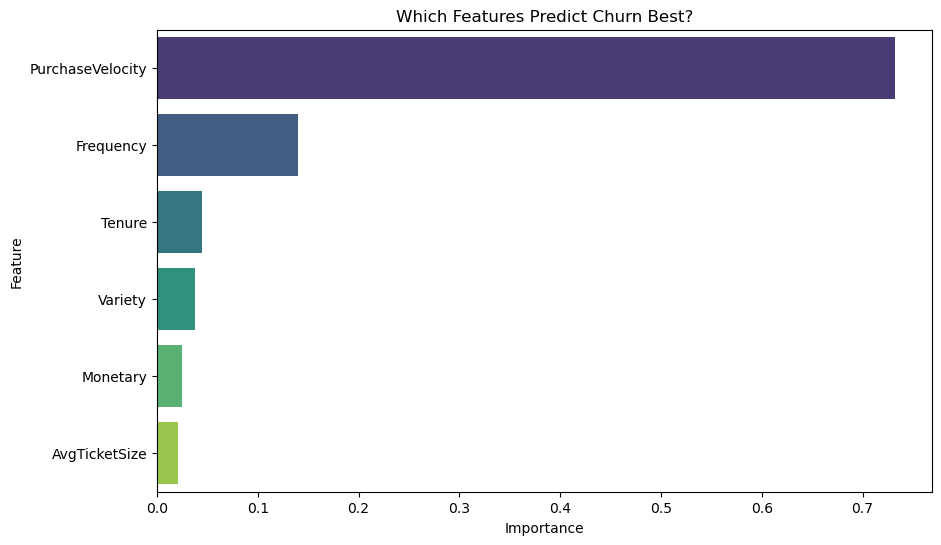

In [20]:

importance = pd.DataFrame({'Feature': features, 'Importance': gbc.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Which Features Predict Churn Best?')
plt.show()

In [21]:
# Get the probability of churn (Class 1)
customer_data['Churn_Probability'] = gbc.predict_proba(X)[:, 1]

# View the top 5 customers most likely to leave
high_risk_customers = customer_data.sort_values(by='Churn_Probability', ascending=False).head(10)
print(high_risk_customers[['Frequency', 'Monetary', 'Churn_Probability']])

             Frequency   Monetary  Churn_Probability
Customer ID                                         
18052.0              1  10877.180           0.995012
17039.0              1   1954.990           0.993343
12671.0              1   2622.481           0.992963
12918.0              1  10953.500           0.992644
16077.0              1   2300.400           0.992442
16917.0              1   1466.310           0.991923
15496.0              1    146.140           0.991304
16716.0              1   1248.480           0.991110
12742.0              1   1201.520           0.990934
17474.0              1   1047.000           0.990596


In [24]:
customer_data

,FirstPurchaseDate,Frequency,Monetary,Tenure,Variety,PurchaseVelocity,AvgTicketSize,Recency,Churn,Churn_Probability
Customer ID,,,,,,,,,,
12346.0,2009-12-14 08:34:00,11,372.86,361,26,0.030387,33.896364,165,1,0.675017
12347.0,2010-10-31 14:20:00,2,1323.32,40,70,0.048780,661.660000,3,0,0.007156
12348.0,2010-09-27 14:59:00,1,222.16,74,20,0.013333,222.160000,74,0,0.014598
12349.0,2010-04-29 13:20:00,3,2671.14,225,90,0.013274,890.380000,43,0,0.118972
12351.0,2010-11-29 15:23:00,1,300.93,11,21,0.083333,300.930000,11,0,0.005866
...,...,...,...,...,...,...,...,...,...,...
18283.0,2010-02-19 17:16:00,6,641.77,294,158,0.020339,106.961667,18,0,0.164342
18284.0,2010-10-04 11:33:00,1,461.68,67,28,0.014706,461.680000,67,0,0.011686
18285.0,2010-02-17 10:24:00,1,427.00,296,12,0.003367,427.000000,296,1,0.988020


In [25]:
customer_data.to_csv('final_data_with_all_features.csv',index=False)